# 03 — Sampling Monte Carlo e metriche audio

In questo notebook vengono analizzati i checkpoint ottenuti dall’esperimento Rate–Distortion, confrontando la ricostruzione deterministica, ottenuta utilizzando z = μ, con la ricostruzione stocastica ottenuta mediante campionamento dal posterior.

La distorsione stocastica D_sample viene stimata tramite campionamento Monte Carlo. L’analisi viene inoltre estesa al dominio audio attraverso MSE, SNR e LogMelMAE, calcolate esclusivamente sulla regione effettivamente contenente il parlato.

L’obiettivo è quantificare il costo introdotto dalla stocasticità del VAE e verificare come questo cambi al diminuire del Rate.


## 1. Preparazione del dataset e rappresentazione STFT

In [1]:
from pathlib import Path
import wave as waveio
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchaudio
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
MC_SAMPLES = 10
SAMPLE_RATE = 8000
N_SAMPLES = 8000
N_FFT = 256
HOP_LENGTH = 64
SPEC_H = SPEC_W = 128
LATENT_DIM = 128
BATCH_SIZE = 64
NOISE_STD = 0.05
PADDING_WEIGHT = 0.10

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

recordings_dir = Path("audio_data/free-spoken-digit-dataset-1.0.10/recordings")
wav_files = sorted(recordings_dir.glob("*.wav"))
if not wav_files:
    raise FileNotFoundError("Dataset FSDD non trovato")

def parse_name(path):
    digit, speaker, index = path.stem.split("_")
    return int(digit), speaker, int(index)

def load_fixed_audio(path):
    with waveio.open(str(path), "rb") as f:
        sr = f.getframerate(); ch = f.getnchannels(); frames = f.readframes(f.getnframes())
    audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    if ch > 1:
        audio = audio.reshape(-1, ch).mean(axis=1)
    x = torch.tensor(audio).unsqueeze(0)
    if sr != SAMPLE_RATE:
        x = torchaudio.functional.resample(x, sr, SAMPLE_RATE)
    valid_length = min(x.shape[1], N_SAMPLES)
    x = F.pad(x, (0, max(0, N_SAMPLES-x.shape[1])))[:, :N_SAMPLES]
    mask = torch.zeros_like(x); mask[:, :valid_length] = 1.0
    return x, mask, valid_length

train_files, test_files = [], []
for p in wav_files:
    _, _, idx = parse_name(p)
    (test_files if idx <= 4 else train_files).append(p)

window = torch.hann_window(N_FFT)
def stft_complex(x):
    return torch.stft(x.squeeze(0), n_fft=N_FFT, hop_length=HOP_LENGTH,
                      win_length=N_FFT, window=window, return_complex=True)
def crop_logmag(x):
    x = x[:SPEC_H, :]
    return F.pad(x, (0, max(0, SPEC_W-x.shape[1])))[:, :SPEC_W]
def frame_weights(valid_length):
    valid_frames = min(int(np.ceil(valid_length/HOP_LENGTH))+1, SPEC_W)
    w = torch.full((1, SPEC_H, SPEC_W), PADDING_WEIGHT)
    w[:, :, :valid_frames] = 1.0
    return w

sum_x = sum_x2 = 0.0; n = 0
for i, p in enumerate(train_files):
    clean, _, _ = load_fixed_audio(p)
    lm = crop_logmag(torch.log1p(stft_complex(clean).abs()))
    sum_x += lm.sum().item()
    sum_x2 += (lm**2).sum().item()
    n += lm.numel()

    if (i + 1) % 100 == 0:
        print(f"Elaborati {i+1} / {len(train_files)} audio")
SPEC_MEAN = sum_x/n
SPEC_STD = max(sum_x2/n - SPEC_MEAN**2, 1e-8)**0.5
print("Train:", len(train_files), "Test:", len(test_files))
print("SPEC_MEAN:", SPEC_MEAN, "SPEC_STD:", SPEC_STD)


Elaborati 100 / 2700 audio
Elaborati 200 / 2700 audio
Elaborati 300 / 2700 audio
Elaborati 400 / 2700 audio
Elaborati 500 / 2700 audio
Elaborati 600 / 2700 audio
Elaborati 700 / 2700 audio
Elaborati 800 / 2700 audio
Elaborati 900 / 2700 audio
Elaborati 1000 / 2700 audio
Elaborati 1100 / 2700 audio
Elaborati 1200 / 2700 audio
Elaborati 1300 / 2700 audio
Elaborati 1400 / 2700 audio
Elaborati 1500 / 2700 audio
Elaborati 1600 / 2700 audio
Elaborati 1700 / 2700 audio
Elaborati 1800 / 2700 audio
Elaborati 1900 / 2700 audio
Elaborati 2000 / 2700 audio
Elaborati 2100 / 2700 audio
Elaborati 2200 / 2700 audio
Elaborati 2300 / 2700 audio
Elaborati 2400 / 2700 audio
Elaborati 2500 / 2700 audio
Elaborati 2600 / 2700 audio
Elaborati 2700 / 2700 audio
Train: 2700 Test: 300
SPEC_MEAN: 0.04547776059049216 SPEC_STD: 0.16703430628401916


## 2. Test set, architettura VAE e checkpoint

In [2]:
class SpectrogramDataset(Dataset):
    def __init__(self, files): self.files = files
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        clean, mask, valid_length = load_fixed_audio(self.files[i])
        g = torch.Generator().manual_seed(10000+i)
        noisy = torch.clamp(clean + NOISE_STD*torch.randn(clean.shape, generator=g)*mask, -1, 1)
        clean_lm = crop_logmag(torch.log1p(stft_complex(clean).abs()))
        noisy_lm = crop_logmag(torch.log1p(stft_complex(noisy).abs()))
        clean_img = ((clean_lm-SPEC_MEAN)/SPEC_STD).unsqueeze(0)
        noisy_img = ((noisy_lm-SPEC_MEAN)/SPEC_STD).unsqueeze(0)
        return noisy_img, clean_img, frame_weights(valid_length)

test_loader = DataLoader(SpectrogramDataset(test_files), batch_size=BATCH_SIZE, shuffle=False)

class STFTVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU())
        self.fc_mu = nn.Linear(128*16*16, LATENT_DIM)
        self.fc_logvar = nn.Linear(128*16*16, LATENT_DIM)
        self.fc_decode = nn.Linear(LATENT_DIM, 128*16*16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1))
    def encode(self,x):
        h=self.encoder(x).flatten(1); return self.fc_mu(h), self.fc_logvar(h)
    def decode(self,z):
        return self.decoder(self.fc_decode(z).view(-1,128,16,16))
    def reparameterize(self,mu,logvar):
        sigma=torch.exp(0.5*logvar); return mu + sigma*torch.randn_like(sigma)

CHECKPOINTS = {
    0.0: CHECKPOINT_DIR / "vae_beta_0e+00.pt",
    1e-6: CHECKPOINT_DIR / "vae_beta_1em06.pt",
    3e-6: CHECKPOINT_DIR / "vae_beta_3em06.pt",
    1e-5: CHECKPOINT_DIR / "vae_beta_1em05.pt",
    3e-5: CHECKPOINT_DIR / "vae_beta_3em05.pt",
    1e-4: CHECKPOINT_DIR / "vae_beta_1em04.pt",
    3e-4: CHECKPOINT_DIR / "vae_beta_3em04.pt",
    1e-3: CHECKPOINT_DIR / "vae_beta_1em03.pt",
    3e-3: CHECKPOINT_DIR / "vae_beta_3em03.pt",
    1e-2: CHECKPOINT_DIR / "vae_beta_1em02.pt"
}
missing=[p for p in CHECKPOINTS.values() if not Path(p).exists()]
if missing:
    raise FileNotFoundError("Checkpoint mancanti: " + ", ".join(missing))
print("Checkpoint trovati:", len(CHECKPOINTS))


Checkpoint trovati: 10


## 3. Calcolo di D_mu, D_sample e Rate

In [3]:
def weighted_mse(recon,target,weights):
    e=(recon-target)**2
    return (e*weights).sum((1,2,3))/weights.sum((1,2,3)).clamp_min(1.0)
def kl_per_example(mu,logvar):
    return -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp(), dim=1)

def evaluate_checkpoint(path):
    model=STFTVAE().to(device)
    model.load_state_dict(torch.load(path,map_location=device)); model.eval()
    tdmu=tds=tr=0.0; count=0
    torch.manual_seed(SEED)
    with torch.no_grad():
        for noisy_img,clean_img,weights in test_loader:
            noisy_img=noisy_img.to(device); clean_img=clean_img.to(device); weights=weights.to(device)
            mu,logvar=model.encode(noisy_img)
            dmu=weighted_mse(model.decode(mu),clean_img,weights)
            ds=torch.zeros_like(dmu)
            for _ in range(MC_SAMPLES):
                ds += weighted_mse(model.decode(model.reparameterize(mu,logvar)),clean_img,weights)
            ds /= MC_SAMPLES
            r=kl_per_example(mu,logvar)
            tdmu += dmu.sum().item(); tds += ds.sum().item(); tr += r.sum().item(); count += clean_img.size(0)
    return tr/count, tdmu/count, tds/count

rows=[]
for beta,path in CHECKPOINTS.items():
    print(f"Valuto beta={beta:.0e}")
    R,Dmu,Ds=evaluate_checkpoint(path)
    rows.append({"beta":beta,"Rate":R,"D_mu":Dmu,"D_sample":Ds})
mc_df=pd.DataFrame(rows).sort_values("beta").reset_index(drop=True)
mc_df


Valuto beta=0e+00
Valuto beta=1e-06
Valuto beta=3e-06
Valuto beta=1e-05
Valuto beta=3e-05
Valuto beta=1e-04
Valuto beta=3e-04
Valuto beta=1e-03
Valuto beta=3e-03
Valuto beta=1e-02


,beta,Rate,D_mu,D_sample
0,0.000000,769.484440,0.248399,0.248443
1,0.000001,718.096224,0.248393,0.248480
2,0.000003,661.143190,0.248369,0.248560
3,0.000010,576.091107,0.248363,0.248891
4,0.000030,472.479225,0.248482,0.249848
5,0.000100,338.115977,0.249429,0.253544
6,0.000300,222.941859,0.252140,0.264340
7,0.001000,122.492573,0.259144,0.298230
8,0.003000,67.326286,0.275989,0.362212
9,0.010000,33.735151,0.322007,0.491691


## 4. Curva Rate–Distortion: ricostruzione deterministica e sampling

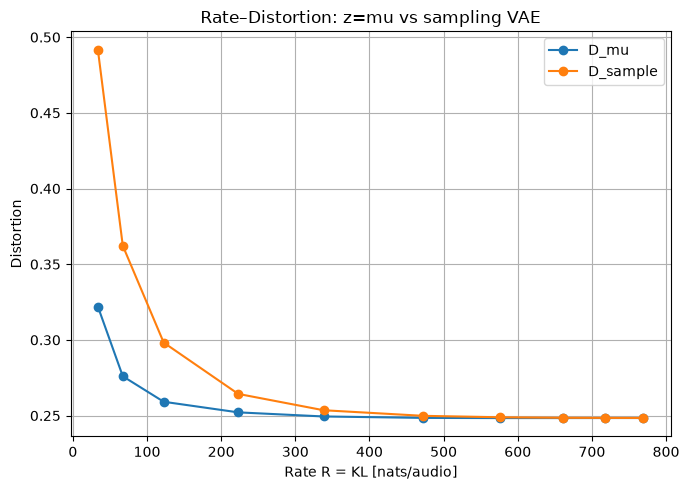

In [10]:
plot_df=mc_df.sort_values("Rate")
plt.figure(figsize=(7,5))
plt.plot(plot_df["Rate"],plot_df["D_mu"],marker="o",label="D_mu")
plt.plot(plot_df["Rate"],plot_df["D_sample"],marker="o",label="D_sample")
plt.xlabel("Rate R = KL [nats/audio]")
plt.ylabel("Distortion")
plt.title("Rate–Distortion: z=mu vs sampling VAE")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "report/figures/rate_distortion.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "report/figures/rate_distortion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 5. Metriche audio sulla regione parlata

In [5]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,n_fft=N_FFT,hop_length=HOP_LENGTH,n_mels=64,power=2.0)

def spec_image_to_wave(recon_norm, phase_source):
    lm = torch.clamp(recon_norm.squeeze(0)*SPEC_STD + SPEC_MEAN, 0.0, 8.0)
    mag128 = torch.expm1(lm)[:, :phase_source.shape[1]]
    mag = torch.cat([mag128, torch.zeros(1,mag128.shape[1])], dim=0)
    comp = mag*torch.exp(1j*torch.angle(phase_source))
    return torch.istft(comp,n_fft=N_FFT,hop_length=HOP_LENGTH,win_length=N_FFT,
                       window=window,length=N_SAMPLES).unsqueeze(0)
def mse_region(a,b): return torch.mean((a-b)**2).item()
def snr_region(a,b):
    return (10*torch.log10((torch.sum(a**2)+1e-12)/(torch.sum((a-b)**2)+1e-12))).item()
def logmel_mae(a,b):
    A=10*torch.log10(mel_transform(a)+1e-10); B=10*torch.log10(mel_transform(b)+1e-10)
    return torch.mean(torch.abs(A-B)).item()

SELECTED=[1e-4,3e-4,1e-3,1e-2]
rows=[]

# noisy baseline
mse_v=[]; snr_v=[]; mel_v=[]
for i,p in enumerate(test_files):
    clean,mask,L=load_fixed_audio(p)
    g=torch.Generator().manual_seed(10000+i)
    noisy=torch.clamp(clean+NOISE_STD*torch.randn(clean.shape,generator=g)*mask,-1,1)
    a=clean[:,:L]; b=noisy[:,:L]
    mse_v.append(mse_region(a,b)); snr_v.append(snr_region(a,b)); mel_v.append(logmel_mae(a,b))
rows.append({"model":"Noisy input","beta":np.nan,"MSE":np.mean(mse_v),"SNR":np.mean(snr_v),"LogMelMAE":np.mean(mel_v)})

for beta in SELECTED:
    print(f"Metriche beta={beta:.0e}")
    model=STFTVAE().to(device); model.load_state_dict(torch.load(CHECKPOINTS[beta],map_location=device)); model.eval()
    mse_v=[]; snr_v=[]; mel_v=[]
    with torch.no_grad():
        for i,p in enumerate(test_files):
            clean,mask,L=load_fixed_audio(p)
            g=torch.Generator().manual_seed(10000+i)
            noisy=torch.clamp(clean+NOISE_STD*torch.randn(clean.shape,generator=g)*mask,-1,1)
            nstft=stft_complex(noisy)
            nlm=crop_logmag(torch.log1p(nstft.abs()))
            nimg=((nlm-SPEC_MEAN)/SPEC_STD).unsqueeze(0).unsqueeze(0).to(device)
            mu,_=model.encode(nimg)
            recon=spec_image_to_wave(model.decode(mu).cpu().squeeze(0),nstft)
            a=clean[:,:L]; b=recon[:,:L]
            mse_v.append(mse_region(a,b)); snr_v.append(snr_region(a,b)); mel_v.append(logmel_mae(a,b))
    rows.append({"model":f"beta={beta:.0e}","beta":beta,"MSE":np.mean(mse_v),"SNR":np.mean(snr_v),"LogMelMAE":np.mean(mel_v)})

audio_metrics_df=pd.DataFrame(rows)
audio_metrics_df


Metriche beta=1e-04
Metriche beta=3e-04
Metriche beta=1e-03
Metriche beta=1e-02


,model,beta,MSE,SNR,LogMelMAE
0,Noisy input,NaN,0.002501,-3.865824,22.702707
1,beta=1e-04,0.0001,0.000470,5.732587,7.137382
2,beta=3e-04,0.0003,0.000485,5.652598,7.136725
3,beta=1e-03,0.0010,0.000510,5.531176,7.193729
4,beta=1e-02,0.0100,0.000745,4.416874,7.815229


## 6. Confronto qualitativo all’ascolto

In [6]:
i=0; p=test_files[i]
clean,mask,L=load_fixed_audio(p)
g=torch.Generator().manual_seed(10000+i)
noisy=torch.clamp(clean+NOISE_STD*torch.randn(clean.shape,generator=g)*mask,-1,1)
nstft=stft_complex(noisy); nlm=crop_logmag(torch.log1p(nstft.abs()))
nimg=((nlm-SPEC_MEAN)/SPEC_STD).unsqueeze(0).unsqueeze(0).to(device)

print("File:",p.name)
print("ORIGINALE"); display(Audio(clean[:,:L].squeeze().numpy(),rate=SAMPLE_RATE))
print("DISTORTO"); display(Audio(noisy[:,:L].squeeze().numpy(),rate=SAMPLE_RATE))

for beta in SELECTED:
    model=STFTVAE().to(device); model.load_state_dict(torch.load(CHECKPOINTS[beta],map_location=device)); model.eval()
    with torch.no_grad():
        mu,logvar=model.encode(nimg)
        recon_mu=spec_image_to_wave(model.decode(mu).cpu().squeeze(0),nstft)
        recon_s=spec_image_to_wave(model.decode(model.reparameterize(mu,logvar)).cpu().squeeze(0),nstft)
    print(f"beta={beta:.0e} — z=mu"); display(Audio(recon_mu[:,:L].squeeze().numpy(),rate=SAMPLE_RATE))
    print(f"beta={beta:.0e} — z campionato"); display(Audio(recon_s[:,:L].squeeze().numpy(),rate=SAMPLE_RATE))


File: 0_george_0.wav
ORIGINALE


DISTORTO


beta=1e-04 — z=mu


beta=1e-04 — z campionato


beta=3e-04 — z=mu


beta=3e-04 — z campionato


beta=1e-03 — z=mu


beta=1e-03 — z campionato


beta=1e-02 — z=mu


beta=1e-02 — z campionato


## 7. Confronto tra ricostruzione deterministica e sampling Monte Carlo
Per i quattro valori di β più rappresentativi vengono confrontate le metriche audio ottenute utilizzando la media del posterior, z = μ, con quelle ottenute campionando dal posterior.
Per il caso stocastico vengono utilizzati 10 campioni Monte Carlo per ciascun segnale.
Il confronto permette di quantificare quanto la componente stocastica del VAE influenzi concretamente la qualità della ricostruzione.

In [8]:
rows = []

for beta in SELECTED:
    print(f"Valuto beta = {beta:.0e}")

    model = STFTVAE().to(device)
    model.load_state_dict(
        torch.load(CHECKPOINTS[beta], map_location=device)
    )
    model.eval()

    mse_mu_values = []
    snr_mu_values = []
    logmel_mu_values = []

    mse_sample_values = []
    snr_sample_values = []
    logmel_sample_values = []

    torch.manual_seed(SEED)

    with torch.no_grad():
        for i, path in enumerate(test_files):
            clean, mask, valid_length = load_fixed_audio(path)

            g = torch.Generator().manual_seed(10000 + i)
            noise = torch.randn(clean.shape, generator=g)

            noisy = torch.clamp(
                clean + NOISE_STD * noise * mask,
                -1.0,
                1.0
            )

            noisy_stft = stft_complex(noisy)
            noisy_logmag = crop_logmag(
                torch.log1p(noisy_stft.abs())
            )

            noisy_img = (
                (noisy_logmag - SPEC_MEAN) / SPEC_STD
            ).unsqueeze(0).unsqueeze(0).to(device)

            mu, logvar = model.encode(noisy_img)

            # Ricostruzione deterministica: z = mu
            recon_mu_norm = model.decode(mu).cpu().squeeze(0)
            recon_mu = spec_image_to_wave(
                recon_mu_norm,
                noisy_stft
            )

            clean_speech = clean[:, :valid_length]
            recon_mu_speech = recon_mu[:, :valid_length]

            mse_mu_values.append(
                mse_region(clean_speech, recon_mu_speech)
            )
            snr_mu_values.append(
                snr_region(clean_speech, recon_mu_speech)
            )
            logmel_mu_values.append(
                logmel_mae(clean_speech, recon_mu_speech)
            )

            # Ricostruzione stocastica: sampling Monte Carlo
            sample_mse = []
            sample_snr = []
            sample_logmel = []

            for _ in range(MC_SAMPLES):
                z = model.reparameterize(mu, logvar)

                recon_sample_norm = (
                    model.decode(z).cpu().squeeze(0)
                )

                recon_sample = spec_image_to_wave(
                    recon_sample_norm,
                    noisy_stft
                )

                recon_sample_speech = (
                    recon_sample[:, :valid_length]
                )

                sample_mse.append(
                    mse_region(
                        clean_speech,
                        recon_sample_speech
                    )
                )
                sample_snr.append(
                    snr_region(
                        clean_speech,
                        recon_sample_speech
                    )
                )
                sample_logmel.append(
                    logmel_mae(
                        clean_speech,
                        recon_sample_speech
                    )
                )

            mse_sample_values.append(np.mean(sample_mse))
            snr_sample_values.append(np.mean(sample_snr))
            logmel_sample_values.append(np.mean(sample_logmel))

    rows.append({
        "beta": beta,
        "MSE_mu": np.mean(mse_mu_values),
        "MSE_sample": np.mean(mse_sample_values),
        "SNR_mu": np.mean(snr_mu_values),
        "SNR_sample": np.mean(snr_sample_values),
        "LogMel_mu": np.mean(logmel_mu_values),
        "LogMel_sample": np.mean(logmel_sample_values)
    })

metrics_sampling_df = pd.DataFrame(rows)
metrics_sampling_df

Valuto beta = 1e-04
Valuto beta = 3e-04
Valuto beta = 1e-03
Valuto beta = 1e-02


,beta,MSE_mu,MSE_sample,SNR_mu,SNR_sample,LogMel_mu,LogMel_sample
0,0.0001,0.000470,0.000478,5.732587,5.670917,7.137382,7.188579
1,0.0003,0.000485,0.000510,5.652598,5.483732,7.136725,7.274350
2,0.0010,0.000510,0.000581,5.531176,5.001658,7.193729,7.640780
3,0.0100,0.000745,0.000958,4.416874,2.942676,7.815229,9.345329


## 8. Salvataggio risultati

In [9]:
mc_df.to_csv(
    RESULTS_DIR / "rate_distortion_sampling.csv",
    index=False
)

audio_metrics_df.to_csv(
    RESULTS_DIR / "audio_metrics_mu.csv",
    index=False
)

metrics_sampling_df.to_csv(
    RESULTS_DIR / "audio_metrics_sampling.csv",
    index=False
)

print("Salvati tutti i risultati in results/")

Salvati tutti i risultati in results/


# Interpretazione finale dei risultati

Il confronto tra ricostruzione deterministica e sampling mostra che la componente stocastica ha un effetto crescente sulla qualità della ricostruzione man mano che il Rate diminuisce.

Per valori moderati di β, la differenza tra D_mu e D_sample rimane contenuta e anche le metriche audio MSE, SNR e LogMelMAE cambiano solo leggermente.

Nei regimi a Rate più basso, invece, il sampling introduce un peggioramento molto più evidente. In particolare, aumentano MSE e LogMelMAE, mentre l’SNR diminuisce.

Questi risultati indicano che la riduzione dell’informazione disponibile nello spazio latente rende la ricostruzione progressivamente più sensibile alla variabilità introdotta dal campionamento del posterior.

L’analisi conferma quindi che lo stochasticity gap non è visibile soltanto nella distorsione spettrale, ma si riflette anche nelle metriche audio.